# Full Thermodynamic RF Pipeline — Research Analysis

End-to-end analysis of the Mac M3 production run:

1. **Training corpus** — 2,395 Rfam balanced thermoswitch / non-switch sequences with ViennaRNA + NUPACK physics features
2. **Generative corpus** — 10,000 de novo RNA sequences from GenerRNA (RunPod)
3. **Classifier** — Random Forest trained on 15 fused physics features, applied to de novo sequences

This notebook addresses questions a methods/results section would typically cover: dataset composition, model discrimination, feature attribution, inter-engine agreement, train→de novo domain shift, prediction calibration, biophysical plausibility of hits, and candidate prioritisation.

In [1]:
%matplotlib inline

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))


DATA = PROJECT_ROOT / "data" / "processed"
FIG_DIR = DATA / "figures" / "full_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

TARGET_TM_LO, TARGET_TM_HI = 37.0, 55.0  # °C design window for bacterial ON switches

## 1. Data loading and pipeline metadata

In [2]:
train = pd.read_csv(DATA / "fused_features.csv")
denovo = pd.read_csv(DATA / "denovo_fused_features.csv")
pred = pd.read_csv(DATA / "denovo_predictions.csv")
payload = joblib.load(DATA / "models" / "rf_thermoswitch.joblib")
model = payload["model"]
feature_cols = payload["feature_columns"]

merged = pred.merge(denovo, on="record_id", how="inner", validate="one_to_one")
assert len(merged) == len(pred), "Prediction / feature row mismatch"

train_clean = train.dropna(subset=["label"] + feature_cols)
denovo_clean = denovo.dropna(subset=feature_cols)

pipeline_meta = {
    "training_rows": len(train_clean),
    "training_pos": int((train_clean["label"] == 1).sum()),
    "training_neg": int((train_clean["label"] == 0).sum()),
    "denovo_rows": len(denovo),
    "predictions": len(pred),
    "predicted_pos": int((pred["predicted_label"] == 1).sum()),
    "predicted_neg": int((pred["predicted_label"] == 0).sum()),
    "n_features": len(feature_cols),
    "temp_grid": "37,41,45,49,53,55 °C",
    "salt": "0.05 M Na+, 0.0 M Mg2+ (NUPACK rna06)",
}
pd.Series(pipeline_meta, name="value").to_frame()

,value
training_rows,2395
training_pos,1198
training_neg,1197
denovo_rows,10000
predictions,9999
predicted_pos,3882
predicted_neg,6117
n_features,15
temp_grid,"37,41,45,49,53,55 °C"
salt,"0.05 M Na+, 0.0 M Mg2+ (NUPACK rna06)"


## 2. Training corpus characterisation

**Research question:** Is the labelled corpus balanced and structurally diverse enough to support supervised learning?

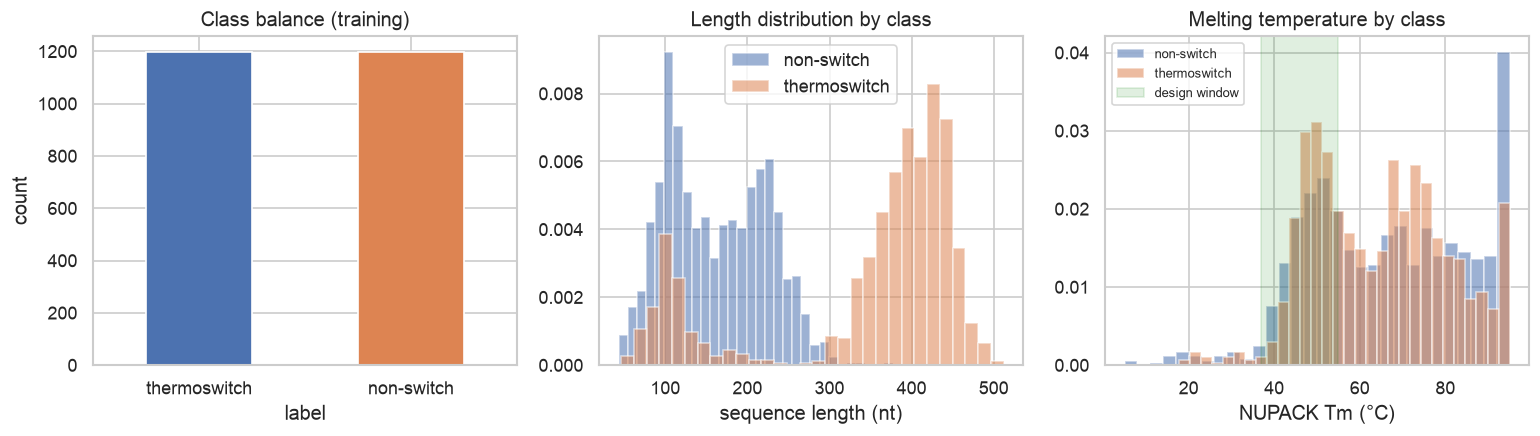

seq_length         nupack_Tm        nupack_amplitude        \
            mean     std      mean    std             mean   std   
label                                                              
0         161.95   60.95     66.75  18.70             0.42  0.22   
1         346.14  121.51     64.63  15.73             0.48  0.21   

      nupack_max_stem_length         
                        mean    std  
label                                
0                      20.09   9.66  
1                      31.07  15.10

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

train_clean["label"].map({0: "non-switch", 1: "thermoswitch"}).value_counts().plot.bar(
    ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title("Class balance (training)")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

for label, color, name in [
    (0, "#4C72B0", "non-switch"),
    (1, "#DD8452", "thermoswitch"),
]:
    subset = train_clean.loc[train_clean["label"] == label, "seq_length"]
    axes[1].hist(subset, bins=30, alpha=0.55, label=name, color=color, density=True)
axes[1].set_xlabel("sequence length (nt)")
axes[1].set_title("Length distribution by class")
axes[1].legend()

for label, color, name in [
    (0, "#4C72B0", "non-switch"),
    (1, "#DD8452", "thermoswitch"),
]:
    subset = train_clean.loc[train_clean["label"] == label, "nupack_Tm"]
    axes[2].hist(subset, bins=30, alpha=0.55, label=name, color=color, density=True)
axes[2].axvspan(
    TARGET_TM_LO, TARGET_TM_HI, color="green", alpha=0.12, label="design window"
)
axes[2].set_xlabel("NUPACK Tm (°C)")
axes[2].set_title("Melting temperature by class")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_training_corpus.png")
plt.show()

train_clean.groupby("label")[
    ["seq_length", "nupack_Tm", "nupack_amplitude", "nupack_max_stem_length"]
].agg(["mean", "std"]).round(2)

## 3. Classifier performance (5-fold stratified CV on Rfam)

**Research question:** How well does a physics-only Random Forest separate known thermoswitches from controls on held-out folds?

We re-fit CV models with the same hyperparameters as production (`n_estimators=200`, `random_state=42`) to report unbiased metrics. The deployed model is trained on all 2,395 rows.

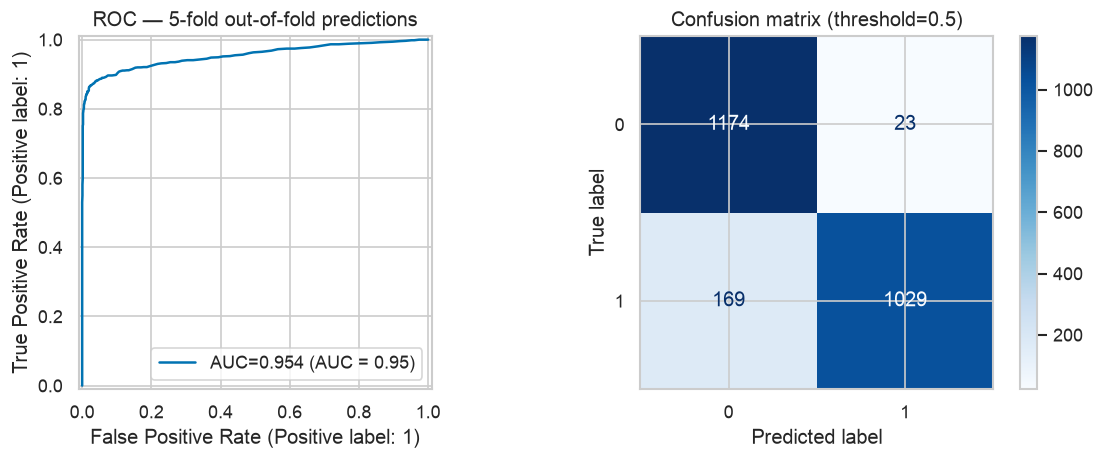

              precision    recall  f1-score   support

  non-switch       0.87      0.98      0.92      1197
thermoswitch       0.98      0.86      0.91      1198

    accuracy                           0.92      2395
   macro avg       0.93      0.92      0.92      2395
weighted avg       0.93      0.92      0.92      2395



In [4]:
X = train_clean[feature_cols]
y = train_clean["label"].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

cv_scores = cross_validate(
    rf_cv,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    {
        metric.replace(
            "test_", ""
        ): f"{cv_scores[metric].mean():.3f} ± {cv_scores[metric].std():.3f}"
        for metric in cv_scores
        if metric.startswith("test_")
    },
    index=["5-fold CV"],
).T
cv_summary.columns = ["mean ± std"]
cv_summary

y_proba_cv = cross_val_predict(rf_cv, X, y, cv=cv, method="predict_proba")[:, 1]
y_pred_cv = (y_proba_cv >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
RocCurveDisplay.from_predictions(
    y, y_proba_cv, ax=axes[0], name=f"AUC={roc_auc_score(y, y_proba_cv):.3f}"
)
axes[0].set_title("ROC — 5-fold out-of-fold predictions")
ConfusionMatrixDisplay.from_predictions(y, y_pred_cv, ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion matrix (threshold=0.5)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_cv_performance.png")
plt.show()

print(classification_report(y, y_pred_cv, target_names=["non-switch", "thermoswitch"]))

## 4. Feature importance and univariate class separation

**Research question:** Which biophysical descriptors drive discrimination — MFE, stem/loop geometry, melting-curve shape, or GC content?

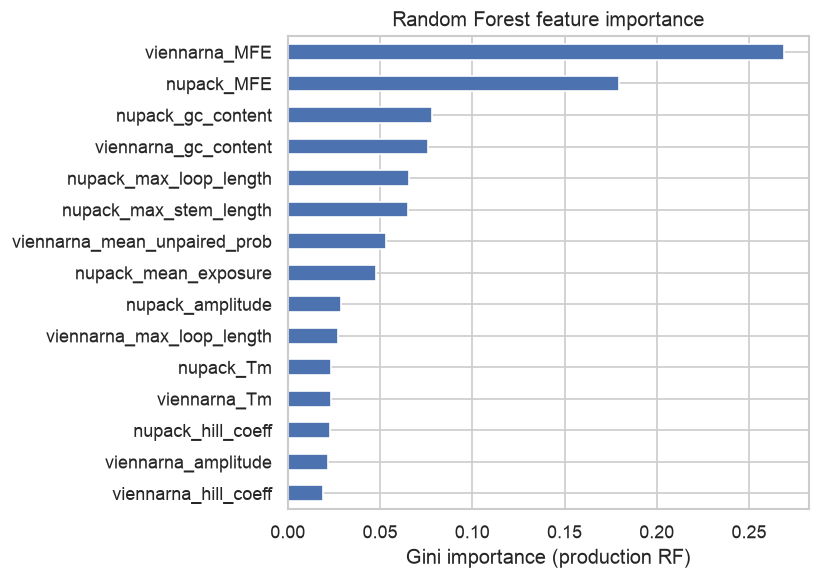

,importance,cohens_d
nupack_MFE,0.179,-1.310
nupack_Tm,0.023,-0.123
nupack_amplitude,0.029,0.254
nupack_gc_content,0.078,-0.629
nupack_hill_coeff,0.023,-0.113
nupack_max_loop_length,0.066,0.811
nupack_max_stem_length,0.065,0.867
nupack_mean_exposure,0.048,-0.089
viennarna_MFE,0.269,-1.569
viennarna_Tm,0.023,0.077


In [5]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 5))
importance.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("Gini importance (production RF)")
ax.set_title("Random Forest feature importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_feature_importance.png")
plt.show()


# Cohen's d effect size per feature (pos vs neg in training)
def cohens_d(a: pd.Series, b: pd.Series) -> float:
    """Return Cohen's d effect size for two numeric samples."""
    return (a.mean() - b.mean()) / np.sqrt(
        (a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2) / 2
    )


pos = train_clean[train_clean["label"] == 1]
neg = train_clean[train_clean["label"] == 0]
effect = pd.Series(
    {col: cohens_d(pos[col], neg[col]) for col in feature_cols}
).sort_values(key=abs, ascending=False)

pd.DataFrame(
    {"importance": importance.sort_values(ascending=False), "cohens_d": effect}
).round(3)

## 5. ViennaRNA vs NUPACK concordance

**Research question:** Do the two physics engines agree on melting temperature and structural proxies, and does agreement differ between classes?

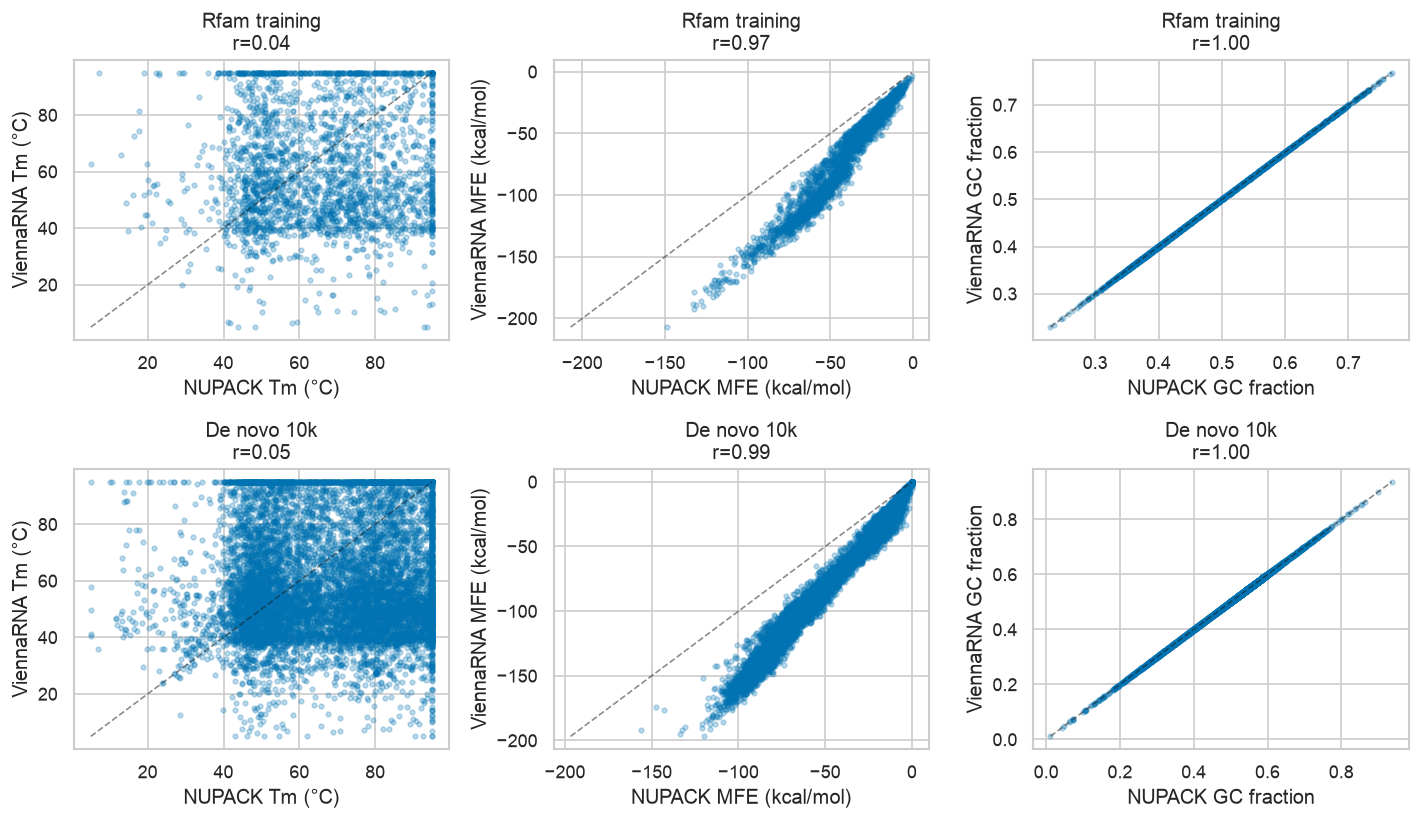

,dataset,pair,r,p
0,Rfam training,Tm (°C),0.0442,0.0306
1,De novo 10k,Tm (°C),0.0468,0.0000
2,Rfam training,MFE (kcal/mol),0.9734,0.0000
3,De novo 10k,MFE (kcal/mol),0.9868,0.0000
4,Rfam training,GC fraction,1.0000,0.0000
5,De novo 10k,GC fraction,1.0000,0.0000


In [6]:
pairs = [
    ("nupack_Tm", "viennarna_Tm", "Tm (°C)"),
    ("nupack_MFE", "viennarna_MFE", "MFE (kcal/mol)"),
    ("nupack_gc_content", "viennarna_gc_content", "GC fraction"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
cor_rows = []

for col, (xcol, ycol, label) in enumerate(pairs):
    for row, (subset, title) in enumerate(
        [(train_clean, "Rfam training"), (denovo_clean, "De novo 10k")]
    ):
        ax = axes[row, col]
        r, p = stats.pearsonr(subset[xcol], subset[ycol])
        cor_rows.append({"dataset": title, "pair": label, "r": r, "p": p})
        ax.scatter(subset[xcol], subset[ycol], s=8, alpha=0.25)
        lims = [
            min(subset[xcol].min(), subset[ycol].min()),
            max(subset[xcol].max(), subset[ycol].max()),
        ]
        ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
        ax.set_xlabel(f"NUPACK {label}")
        ax.set_ylabel(f"ViennaRNA {label}")
        ax.set_title(f"{title}\nr={r:.2f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_engine_concordance.png")
plt.show()

pd.DataFrame(cor_rows).round(4)

## 6. Domain shift: Rfam training → GenerRNA de novo

**Research question:** Does the generative model produce sequences whose physics feature distributions differ from natural Rfam switches (covariate shift)?

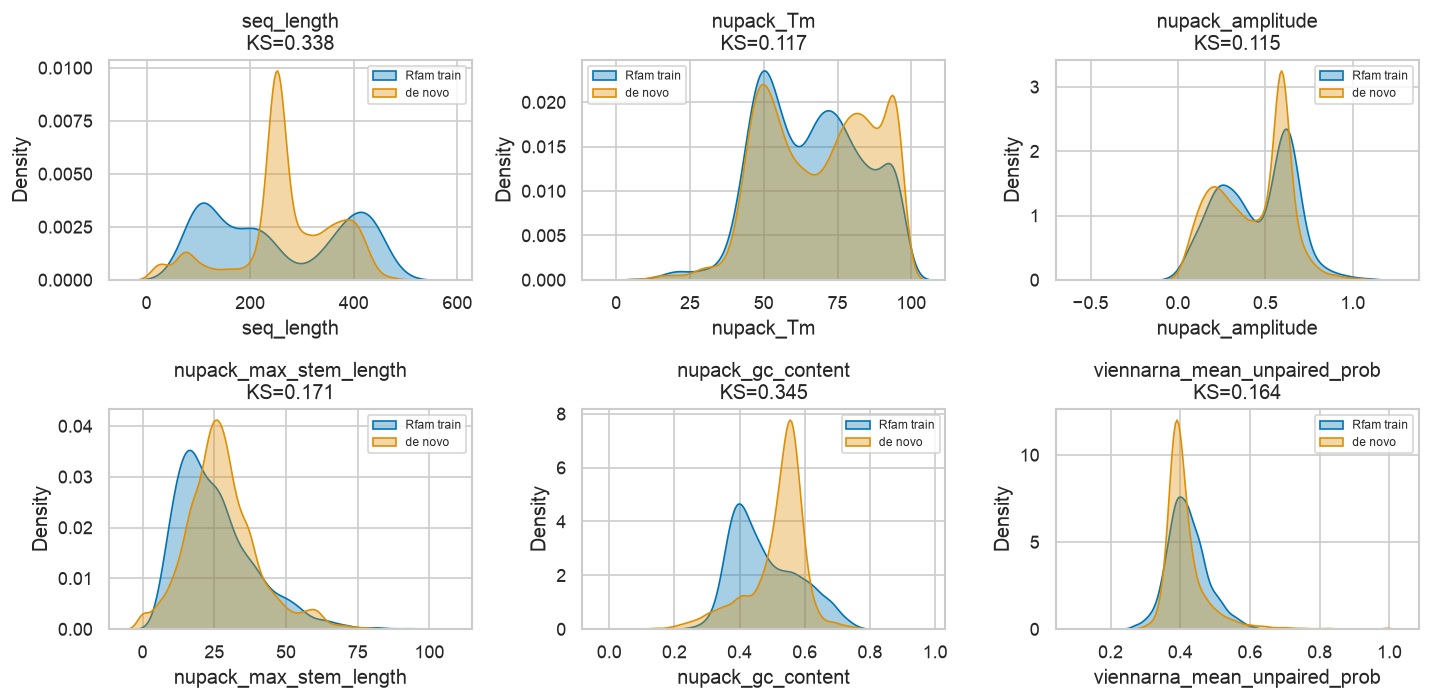

,feature,ks_stat,p_value
4,nupack_gc_content,0.3451,0.0
0,seq_length,0.3384,0.0
3,nupack_max_stem_length,0.1708,0.0
5,viennarna_mean_unpaired_prob,0.1639,0.0
1,nupack_Tm,0.1166,0.0
2,nupack_amplitude,0.1151,0.0


In [7]:
shift_features = [
    "seq_length",
    "nupack_Tm",
    "nupack_amplitude",
    "nupack_max_stem_length",
    "nupack_gc_content",
    "viennarna_mean_unpaired_prob",
]

ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for ax, feat in zip(axes, shift_features):
    a = train_clean[feat].dropna()
    b = denovo_clean[feat].dropna()
    stat, p = stats.ks_2samp(a, b)
    ks_rows.append({"feature": feat, "ks_stat": stat, "p_value": p})
    sns.kdeplot(a, ax=ax, label="Rfam train", fill=True, alpha=0.35)
    sns.kdeplot(b, ax=ax, label="de novo", fill=True, alpha=0.35)
    ax.set_title(f"{feat}\nKS={stat:.3f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_domain_shift.png")
plt.show()

pd.DataFrame(ks_rows).sort_values("ks_stat", ascending=False).round(4)

## 7. De novo prediction landscape

**Research question:** What fraction of AI-generated sequences are classified as thermoswitches, and how confident are those calls?

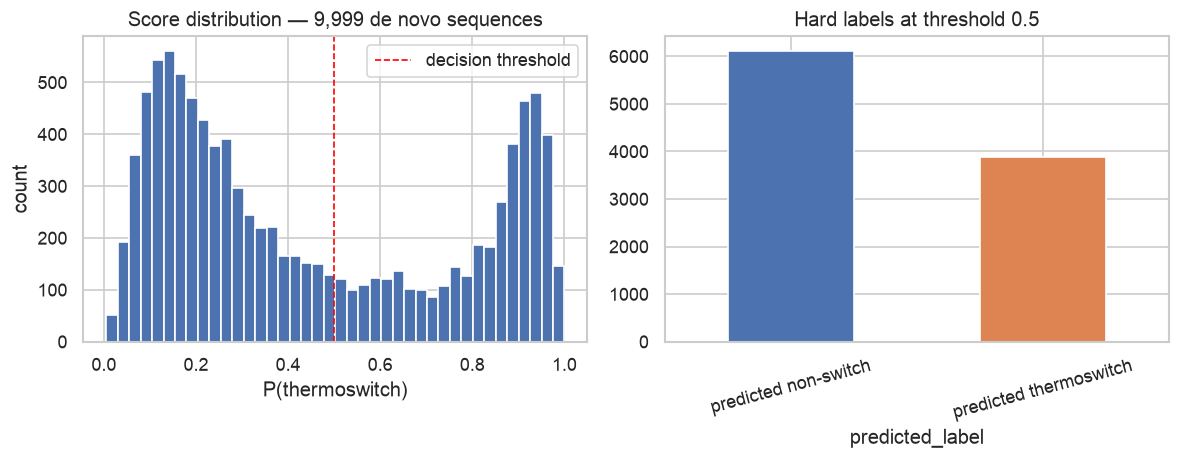

Hit rate (label=1): 38.8%  (3,882 / 9,999)
High-confidence hits (P≥0.9): 1,566 (15.7%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(merged["prob_positive"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(0.5, color="red", ls="--", lw=1, label="decision threshold")
axes[0].set_xlabel("P(thermoswitch)")
axes[0].set_ylabel("count")
axes[0].set_title("Score distribution — 9,999 de novo sequences")
axes[0].legend()

merged["predicted_label"].map(
    {0: "predicted non-switch", 1: "predicted thermoswitch"}
).value_counts().plot.bar(ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Hard labels at threshold 0.5")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_prediction_landscape.png")
plt.show()

hit_rate = merged["predicted_label"].mean()
high_conf = (merged["prob_positive"] >= 0.9).sum()
print(
    f"Hit rate (label=1): {hit_rate:.1%}  ({merged['predicted_label'].sum():,} / {len(merged):,})"
)
print(f"High-confidence hits (P≥0.9): {high_conf:,} ({high_conf / len(merged):.1%})")

## 8. Biophysical plausibility of predicted positives

**Research question:** Do predicted thermoswitches exhibit switch-like melting behaviour (sigmoidal amplitude, Tm near the design window, adequate stem/loop geometry)?

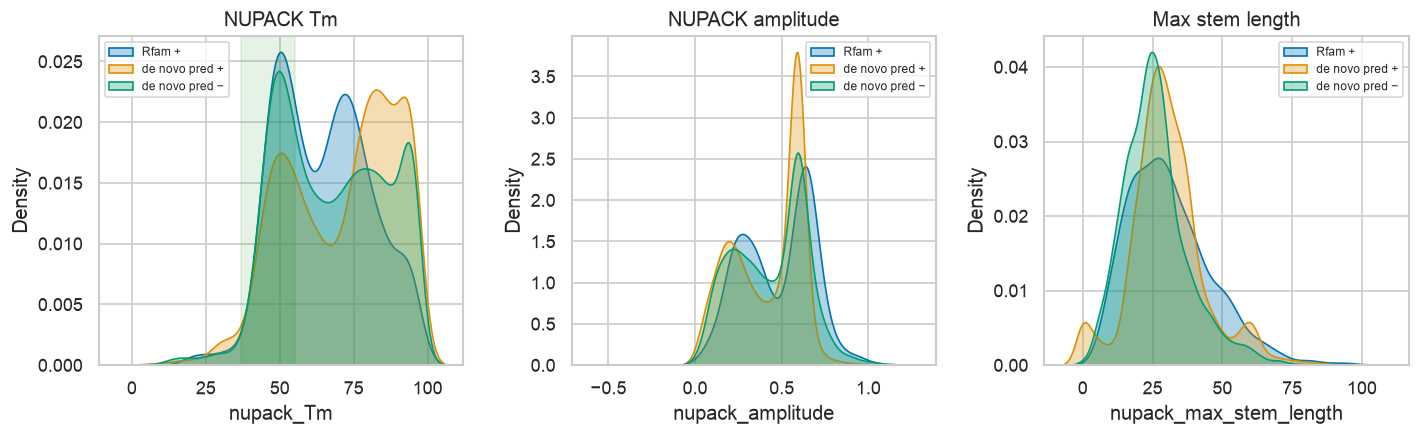

In [9]:
pred_pos = merged[merged["predicted_label"] == 1]
pred_neg = merged[merged["predicted_label"] == 0]
train_pos = train_clean[train_clean["label"] == 1]

bio_metrics = []
for name, df in [
    ("Rfam positives (reference)", train_pos),
    ("Predicted de novo positives", pred_pos),
    ("Predicted de novo negatives", pred_neg),
]:
    in_window = (
        (df["nupack_Tm"] >= TARGET_TM_LO) & (df["nupack_Tm"] <= TARGET_TM_HI)
    ).mean()
    bio_metrics.append(
        {
            "cohort": name,
            "n": len(df),
            "nupack_Tm_mean": df["nupack_Tm"].mean(),
            "nupack_amplitude_mean": df["nupack_amplitude"].mean(),
            "nupack_hill_mean": df["nupack_hill_coeff"].mean(),
            "stem_len_mean": df["nupack_max_stem_length"].mean(),
            "loop_len_mean": df["nupack_max_loop_length"].mean(),
            "frac_Tm_in_37_55C": in_window,
        }
    )
bio_df = pd.DataFrame(bio_metrics).round(3)
bio_df

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, feat, title in zip(
    axes,
    ["nupack_Tm", "nupack_amplitude", "nupack_max_stem_length"],
    ["NUPACK Tm", "NUPACK amplitude", "Max stem length"],
):
    sns.kdeplot(train_pos[feat], ax=ax, label="Rfam +", fill=True, alpha=0.3)
    sns.kdeplot(pred_pos[feat], ax=ax, label="de novo pred +", fill=True, alpha=0.3)
    sns.kdeplot(pred_neg[feat], ax=ax, label="de novo pred −", fill=True, alpha=0.3)
    if feat == "nupack_Tm":
        ax.axvspan(TARGET_TM_LO, TARGET_TM_HI, color="green", alpha=0.1)
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_biophysical_plausibility.png")
plt.show()

## 9. Score vs biophysics — does the RF track known switch signatures?

**Research question:** Are higher RF scores associated with stronger melting transitions and more switch-like Tm values on de novo sequences?

/var/folders/qr/4gk79s7x0v5b3shzgzpkx89h0000gn/T/ipykernel_72674/175062798.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


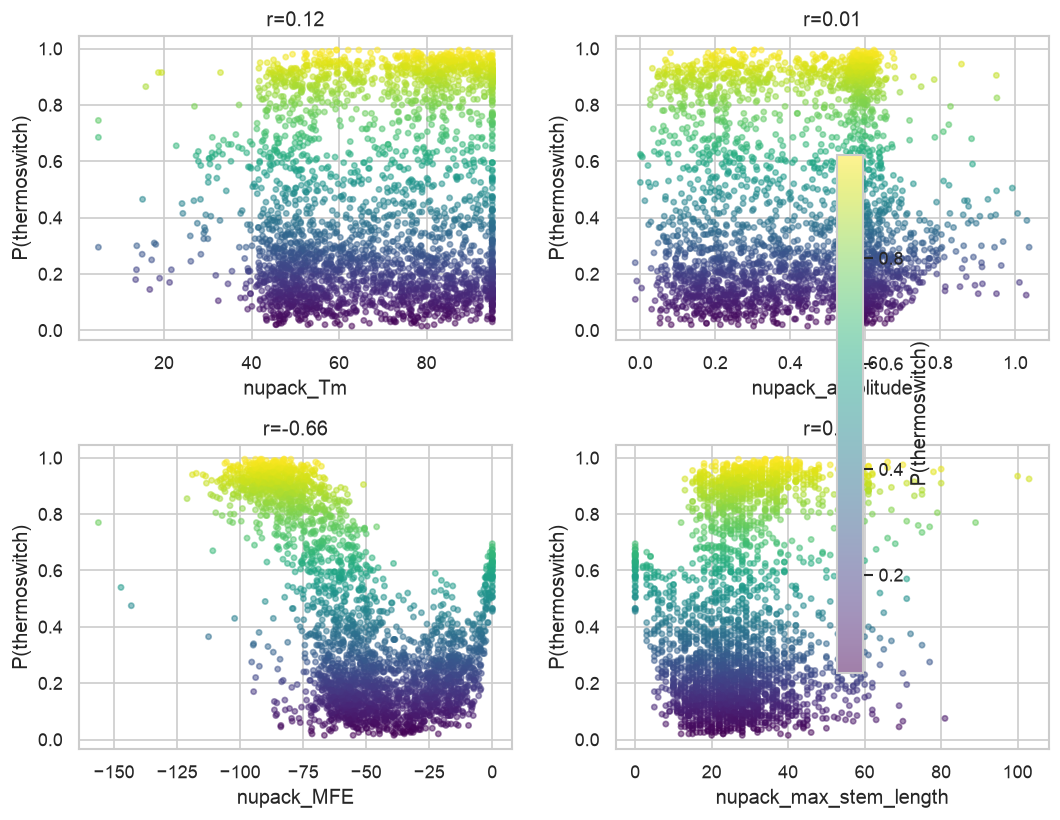

In [10]:
scatter_feats = [
    "nupack_Tm",
    "nupack_amplitude",
    "nupack_MFE",
    "nupack_max_stem_length",
]
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, feat in zip(axes.ravel(), scatter_feats):
    sub = merged.sample(min(3000, len(merged)), random_state=42)
    sc = ax.scatter(
        sub[feat],
        sub["prob_positive"],
        c=sub["prob_positive"],
        cmap="viridis",
        s=10,
        alpha=0.5,
    )
    r, p = stats.pearsonr(merged[feat], merged["prob_positive"])
    ax.set_xlabel(feat)
    ax.set_ylabel("P(thermoswitch)")
    ax.set_title(f"r={r:.2f}")
fig.colorbar(sc, ax=axes.ravel().tolist(), label="P(thermoswitch)", shrink=0.8)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_score_vs_biophysics.png")
plt.show()

## 10. Candidate prioritisation for experimental validation

**Research question:** Which de novo sequences should be synthesised first?

We rank by RF probability and apply biophysical filters:
- NUPACK Tm within 37–55 °C (ON at physiological temperature)
- NUPACK amplitude ≥ 0.15 (detectable melting transition)
- Hill coefficient ≥ 2 (cooperative transition)
- Vienna + NUPACK fit status = `ok`

In [11]:
candidates = merged[
    (merged["prob_positive"] >= 0.9)
    & (merged["nupack_Tm"].between(TARGET_TM_LO, TARGET_TM_HI))
    & (merged["nupack_amplitude"] >= 0.15)
    & (merged["nupack_hill_coeff"] >= 2)
    & (merged["nupack_fit_status"] == "ok")
    & (merged["viennarna_fit_status"] == "ok")
].copy()

candidates["priority_score"] = (
    candidates["prob_positive"]
    + 0.15 * candidates["nupack_amplitude"].clip(0, 1)
    + 0.05 * (candidates["nupack_hill_coeff"].clip(0, 20) / 20)
)
candidates = candidates.sort_values("priority_score", ascending=False)

display_cols = [
    "record_id",
    "prob_positive",
    "priority_score",
    "seq_length",
    "nupack_Tm",
    "nupack_amplitude",
    "nupack_hill_coeff",
    "nupack_max_stem_length",
    "nupack_max_loop_length",
    "nupack_gc_content",
]
print(f"Filtered candidates passing all gates: {len(candidates):,}")
candidates[display_cols].head(20)

Filtered candidates passing all gates: 99


,record_id,prob_positive,priority_score,seq_length,nupack_Tm,nupack_amplitude,nupack_hill_coeff,nupack_max_stem_length,nupack_max_loop_length,nupack_gc_content
297,sample_297,0.995,1.039964,413,51.974615,0.205393,5.662100,31,30,0.527845
5115,sample_5115,0.995,1.038573,370,44.327610,0.237715,3.166483,33,18,0.518919
5217,sample_5217,0.980,1.034393,404,49.359347,0.273292,5.359541,43,32,0.497525
8664,sample_8665,0.980,1.032000,414,52.588475,0.300132,2.792005,32,17,0.531401
2971,sample_2971,0.985,1.027965,424,47.458214,0.214237,4.331778,65,21,0.516509
3904,sample_3904,0.985,1.027178,372,48.634009,0.202086,4.746237,52,14,0.526882
6366,sample_6366,0.985,1.024513,429,54.616985,0.180778,4.958429,42,19,0.522145
3835,sample_3835,0.980,1.019678,381,52.362475,0.208490,3.361945,46,24,0.545932
3438,sample_3438,0.980,1.019307,485,49.833551,0.178622,5.005541,31,27,0.519588
7708,sample_7709,0.975,1.017020,407,52.446797,0.191421,5.322932,33,15,0.530713


In [12]:
export_path = DATA / "denovo_top_candidates.csv"
candidates[display_cols].to_csv(export_path, index=False)
print(f"Exported top candidates table → {export_path}")

Exported top candidates table → /Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/data/processed/denovo_top_candidates.csv


## 11. Synthesis — key findings for a paper

Run the cell below to emit a JSON summary suitable for a results paragraph or supplementary table.

In [13]:
summary = {
    "methods": pipeline_meta,
    "cv_performance": {
        k.replace("test_", ""): float(cv_scores[k].mean())
        for k in cv_scores
        if k.startswith("test_")
    },
    "top_features": importance.sort_values(ascending=False).head(5).round(4).to_dict(),
    "denovo_predictions": {
        "hit_rate_0.5": float(hit_rate),
        "high_conf_ge_0.9": int(high_conf),
        "filtered_candidates": int(len(candidates)),
    },
    "biophysical_cohorts": bio_df.to_dict(orient="records"),
    "limitations": [
        "No experimental ground truth for de novo hits — all labels are model-derived.",
        "Training labels are Rfam homology clusters, not wet-lab validated switches.",
        "Sparse temperature grid (6 points) may bias Hill/Tm fits vs full 10–80 °C prototype panel.",
        "One Rfam sequence skipped (IUPAC ambiguity); one de novo sequence has flat Vienna fit.",
        "Generative sequences may sit outside Rfam manifold (KS domain shift on several features).",
    ],
}

summary_path = DATA / "full_analysis_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print(f"\nSaved → {summary_path}")

{
  "methods": {
    "training_rows": 2395,
    "training_pos": 1198,
    "training_neg": 1197,
    "denovo_rows": 10000,
    "predictions": 9999,
    "predicted_pos": 3882,
    "predicted_neg": 6117,
    "n_features": 15,
    "temp_grid": "37,41,45,49,53,55 \u00b0C",
    "salt": "0.05 M Na+, 0.0 M Mg2+ (NUPACK rna06)"
  },
  "cv_performance": {
    "accuracy": 0.918580375782881,
    "precision": 0.9780688856768549,
    "recall": 0.8564365411436542,
    "f1": 0.9131533273215856,
    "roc_auc": 0.9547611576011157
  },
  "top_features": {
    "viennarna_MFE": 0.269,
    "nupack_MFE": 0.1795,
    "nupack_gc_content": 0.0781,
    "viennarna_gc_content": 0.0757,
    "nupack_max_loop_length": 0.0656
  },
  "denovo_predictions": {
    "hit_rate_0.5": 0.38823882388238823,
    "high_conf_ge_0.9": 1566,
    "filtered_candidates": 99
  },
  "biophysical_cohorts": [
    {
      "cohort": "Rfam positives (reference)",
      "n": 1198,
      "nupack_Tm_mean": 64.632,
      "nupack_amplitude_mean": 0

### Interpretation checklist

| Question | Where answered |
|---|---|
| Is the training set balanced? | §2 |
| Does physics-only RF discriminate known switches? | §3 (AUC ~0.95 CV) |
| Which features matter most? | §4 (MFE dominates; GC, stem/loop secondary) |
| Do ViennaRNA and NUPACK agree? | §5 |
| Is there covariate shift to GenerRNA? | §6 (KS tests) |
| What is the de novo hit rate? | §7 (~39% at 0.5 threshold) |
| Are hits biophysically plausible? | §8–9 |
| What to synthesise first? | §10 (`denovo_top_candidates.csv`) |

**Suggested next experiments:** FRET or SHAPE-MaP melting curves on top-20 candidates; compare predicted Tm/amplitude to measured; use BiRNA-BERT embeddings (already in S3) for a hybrid physics+sequence model ablation.